# Uczenie maszynowe Lista 3

najpierw pobieramy dane i zrobimy sobie analizę zbioru

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler

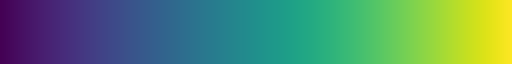

In [64]:
sns.color_palette("viridis", as_cmap=True)

In [65]:
problemy_sercowe = pd.read_csv("data/Heart_disease_cleveland_new.csv")
problemy_sercowe.shape

(303, 14)

In [66]:
problemy_sercowe.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [67]:
problemy_sercowe.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [68]:
problemy_sercowe.drop_duplicates(inplace=True)
problemy_sercowe.shape

(303, 14)

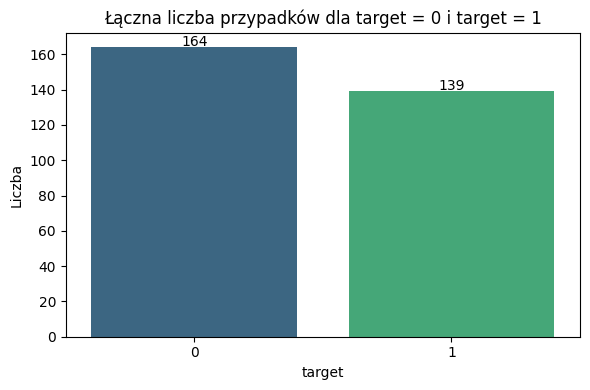

In [69]:
target_counts = problemy_sercowe["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    hue=target_counts.index,
    palette="viridis",
    legend=False,
    )
plt.title("Łączna liczba przypadków dla target = 0 i target = 1")
plt.xlabel("target")
plt.ylabel("Liczba")
plt.xticks([0, 1], ["0", "1"])

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

target      1.000000
thal        0.515894
ca          0.460033
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64


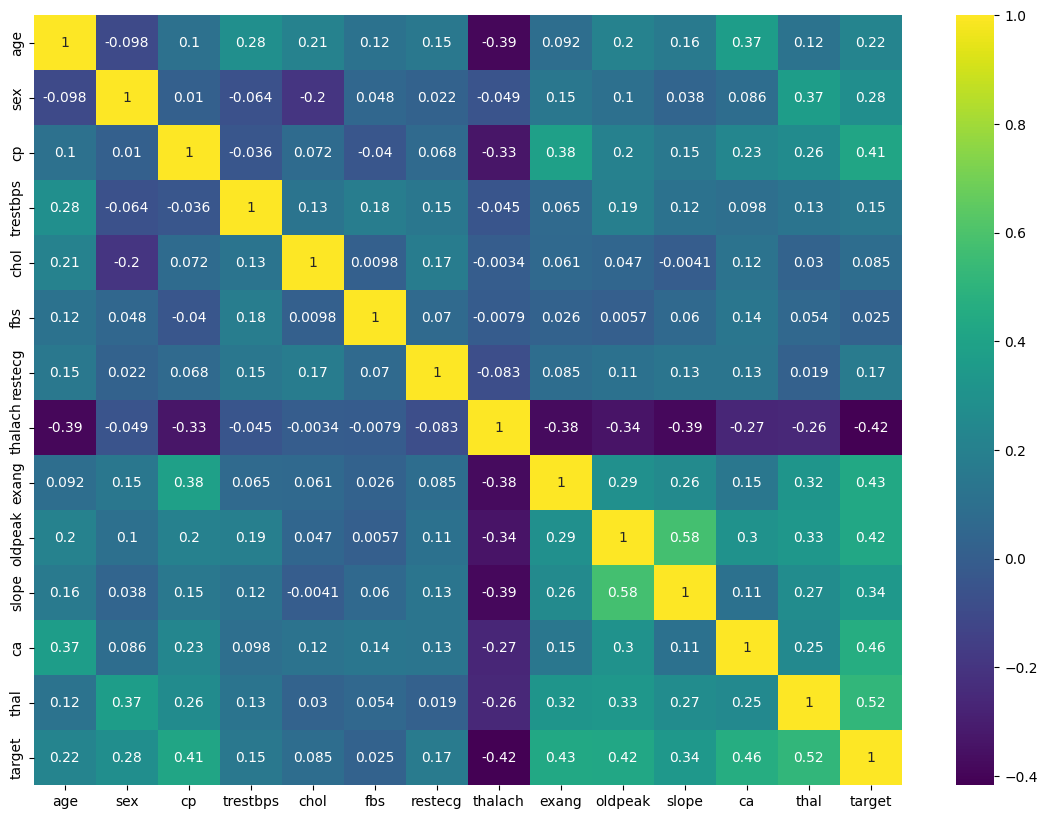

In [70]:
plt.figure(figsize=(14, 10))
sns.heatmap(problemy_sercowe.corr(numeric_only=True), annot=True, cmap='viridis')

corr_with_survived = problemy_sercowe.corr(numeric_only=True)['target'].abs().sort_values(ascending=False)
print(corr_with_survived)


X_train: (242, 13) X_test: (61, 13)
y_train: (242,) y_test: (61,)


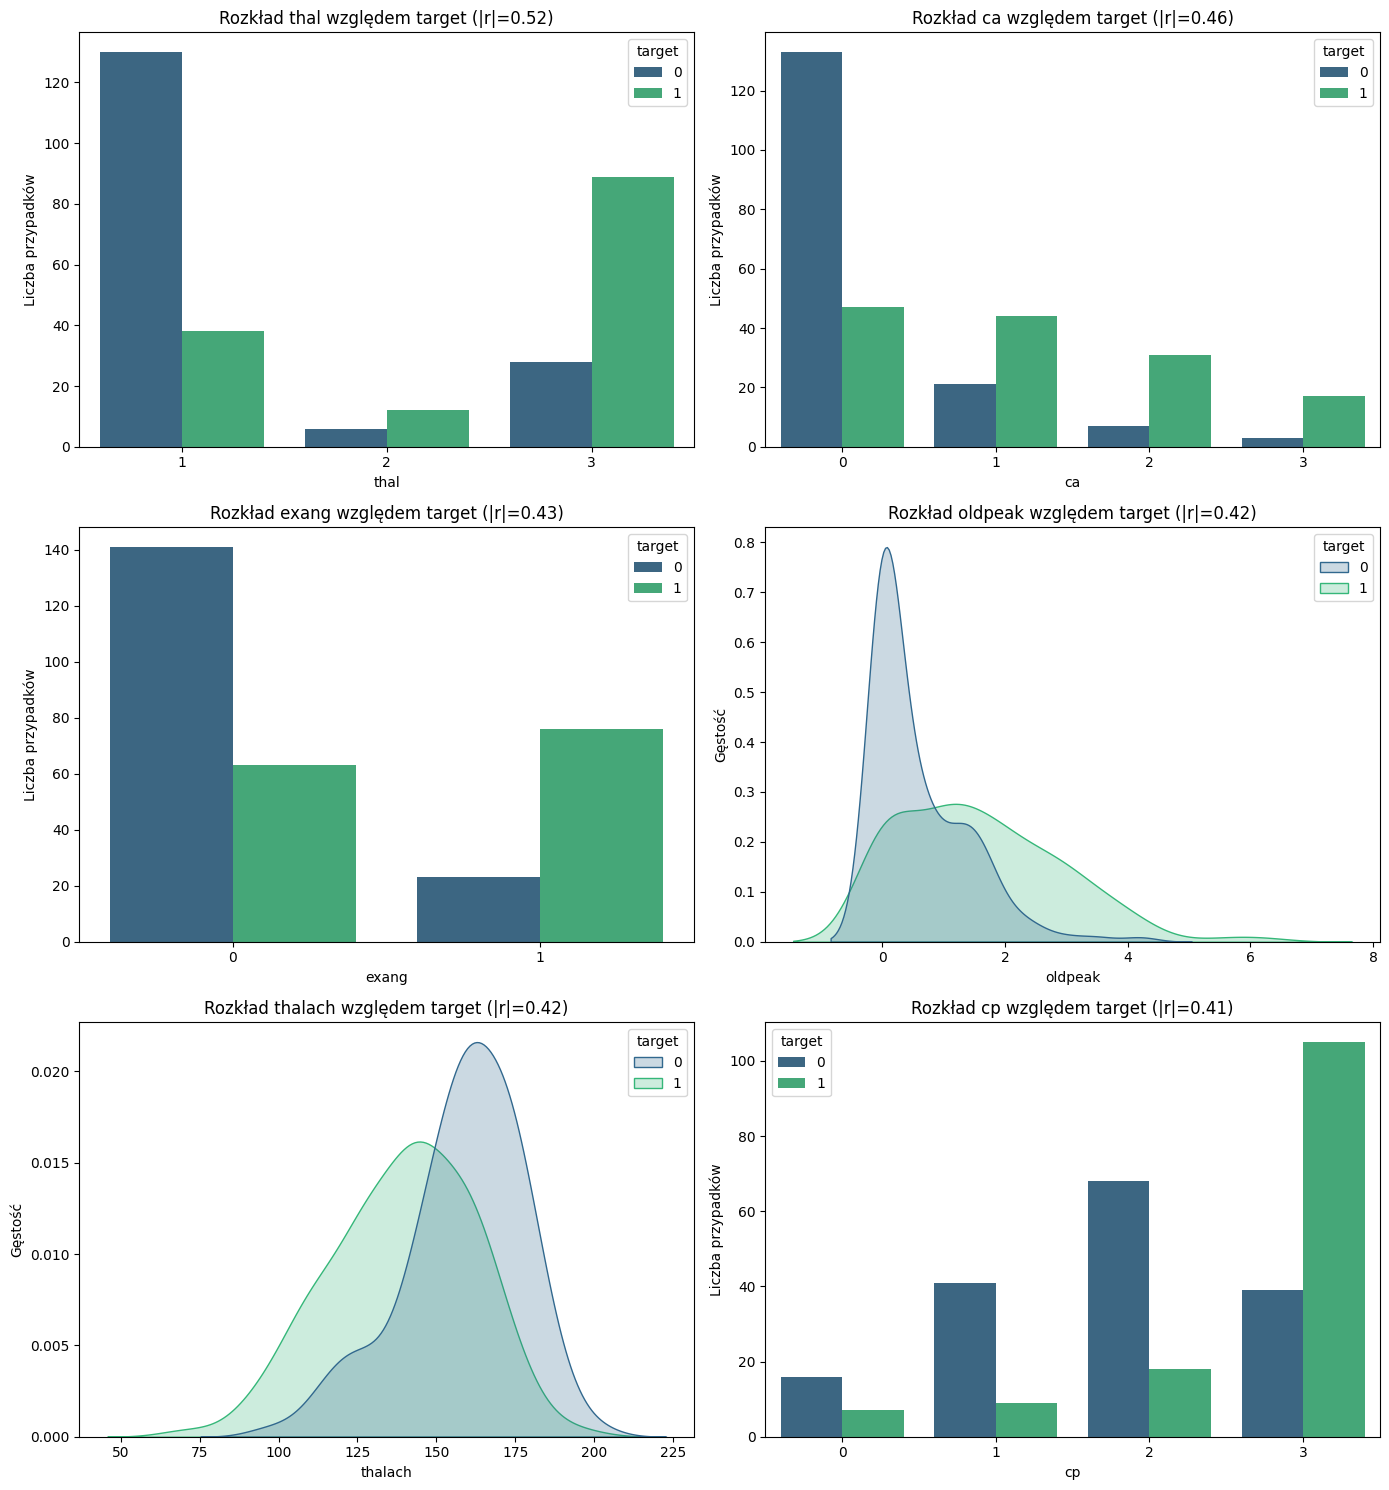

Atrybuty z |korelacja| >= 0.40: ['thal', 'ca', 'exang', 'oldpeak', 'thalach', 'cp']


In [71]:
X = problemy_sercowe.drop(columns="target")
y = problemy_sercowe["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("X_train:", X_train_scaled.shape, "X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

threshold = 0.40
corr_with_target = problemy_sercowe.corr(numeric_only=True)["target"].drop("target")
strong_features = corr_with_target[corr_with_target.abs() >= threshold].sort_values(key=np.abs, ascending=False).index.tolist()

n_cols = 2
n_rows = int(np.ceil(len(strong_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, feature in zip(axes, strong_features):
    n_unique = problemy_sercowe[feature].nunique(dropna=True)

    if n_unique <= 10:
        order_vals = sorted(problemy_sercowe[feature].dropna().unique().tolist())
        sns.countplot(
            data=problemy_sercowe,
            x=feature,
            hue="target",
            order=order_vals,
            palette="viridis",
            ax=ax
        )
        ax.set_xlabel(feature)
        ax.set_ylabel("Liczba przypadków")
        ax.legend(title="target")
    else:
        sns.kdeplot(
            data=problemy_sercowe,
            x=feature,
            hue="target",
            palette="viridis",
            fill=True,
            common_norm=False,
            ax=ax
        )
        ax.set_xlabel(feature)
        ax.set_ylabel("Gęstość")

    ax.set_title(f"Rozkład {feature} względem target (|r|={abs(corr_with_target[feature]):.2f})")

for ax in axes[len(strong_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

print("Atrybuty z |korelacja| >= 0.40:", strong_features)

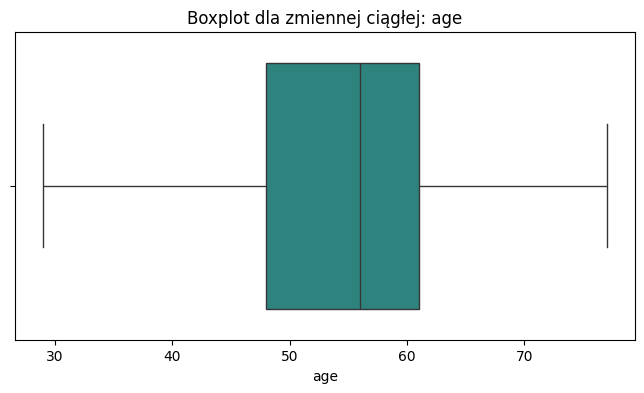

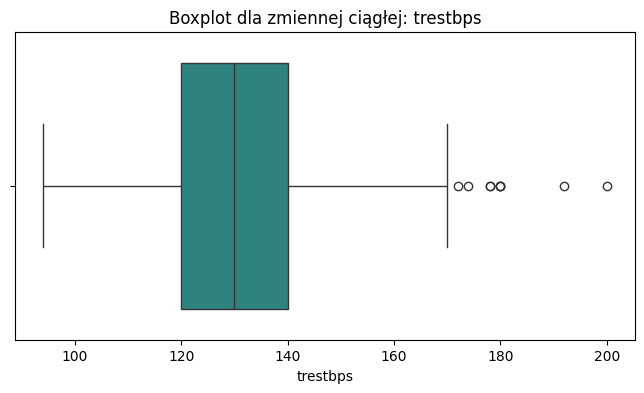

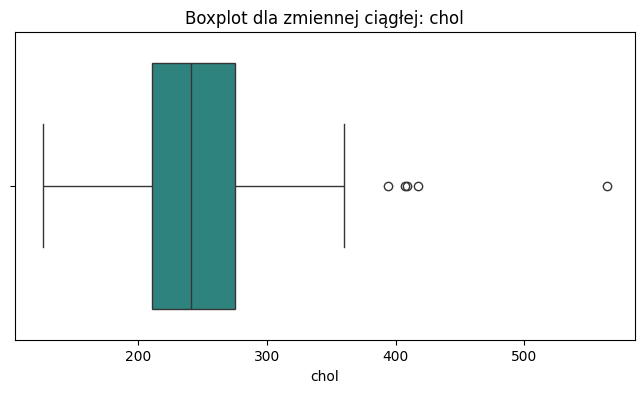

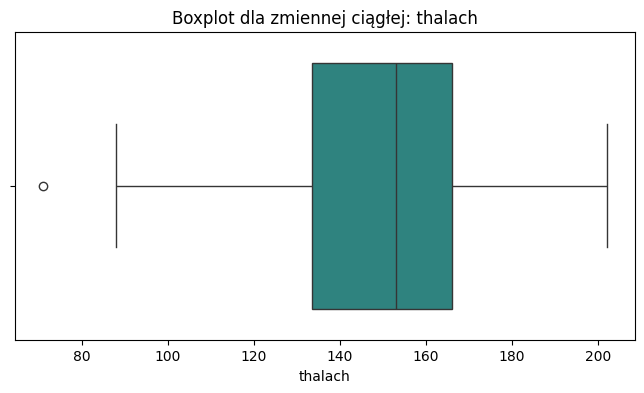

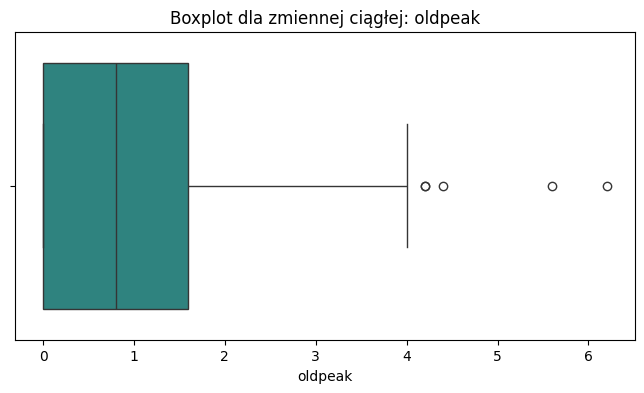

In [72]:
for col in problemy_sercowe.columns:
    if problemy_sercowe[col].nunique() > 4: 
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=problemy_sercowe[col], color=sns.color_palette("viridis", 3)[1])
        plt.title(f"Boxplot dla zmiennej ciągłej: {col}")
        plt.show()

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

def build_logreg_pipeline(
    scaler=None,
    penalty="l2",
    C=0.1,
    solver="lbfgs",
    l1_ratio=None,
    max_iter=4000,
    ):
    numeric_transformer = "passthrough" if scaler is None else scaler
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    if penalty == "l2":
        effective_l1_ratio = 0.0
        effective_C = C
    elif penalty == "l1":
        effective_l1_ratio = 1.0
        effective_C = C
    elif penalty == "elasticnet":
        if l1_ratio is None:
            raise ValueError("Dla penalty='elasticnet' trzeba podać l1_ratio.")
        effective_l1_ratio = l1_ratio
        effective_C = C
    elif penalty in (None, "none"):
        effective_l1_ratio = 0.0
        effective_C = np.inf
    else:
        raise ValueError("Nieobsługiwany typ regularyzacji.")

    classifier = LogisticRegression(
        C=effective_C,
        solver=solver,
        l1_ratio=effective_l1_ratio,
        max_iter=max_iter,
        random_state=42,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier),
        ]
    )

print("Podział danych gotowy:", X_train.shape, X_test.shape)
print("Zmienne numeryczne:", numeric_features)
print("Zmienne kategorialne:", categorical_features)

Podział danych gotowy: (242, 13) (61, 13)
Zmienne numeryczne: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Zmienne kategorialne: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


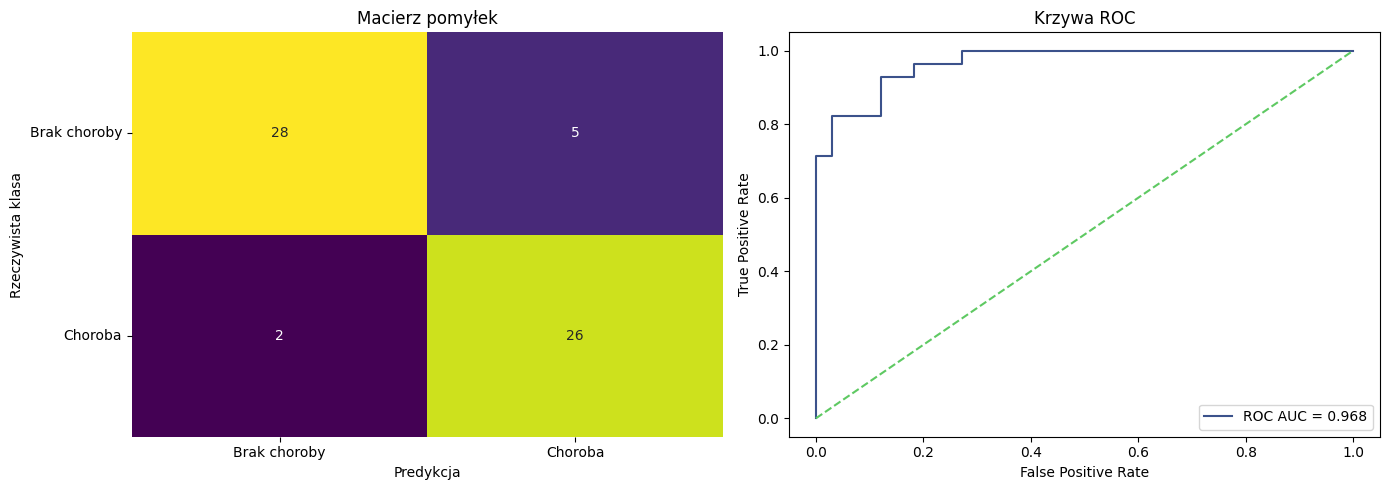

Accuracy: 0.885
Precision: 0.839
Recall: 0.929
ROC AUC: 0.968

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61


Macierz pomyłek:
 [[28  5]
 [ 2 26]]


In [74]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    )

baseline_model = build_logreg_pipeline(
    penalty="l2",
    C=0.1,
    scaler=RobustScaler(),
    solver="lbfgs",
    max_iter=4000,
    )
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

viridis_palette = sns.color_palette("viridis", 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    cbar=False,
    ax=axes[0],
    )
axes[0].set_title("Macierz pomyłek")
axes[0].set_xlabel("Predykcja")
axes[0].set_ylabel("Rzeczywista klasa")
axes[0].set_xticklabels(["Brak choroby", "Choroba"])
axes[0].set_yticklabels(["Brak choroby", "Choroba"], rotation=0)

axes[1].plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}", color=viridis_palette[0])
axes[1].plot([0, 1], [0, 1], linestyle="--", color=viridis_palette[2])
axes[1].set_title("Krzywa ROC")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("ROC AUC:", round(roc_auc, 3))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))
print("\nMacierz pomyłek:\n", cm)

### Interpretacja metryk modelu bazowego

- Precision pokazuje, jaki odsetek pacjentów przewidzianych jako chorzy jest faktycznie chory.
- Recall pokazuje, jaki odsetek rzeczywiście chorych został wykryty przez model.
- W kontekście medycznym zwykle ważniejsza jest wysoka czułość, aby ograniczyć liczbę pominiętych przypadków choroby.

,Accuracy,Precision,Recall,ROC AUC
Metoda skalowania,,,,
Brak skalowania,0.902,0.867,0.929,0.959
Standaryzacja (StandardScaler),0.885,0.839,0.929,0.965
Normalizacja (MinMaxScaler),0.869,0.857,0.857,0.953
RobustScaler,0.885,0.839,0.929,0.968


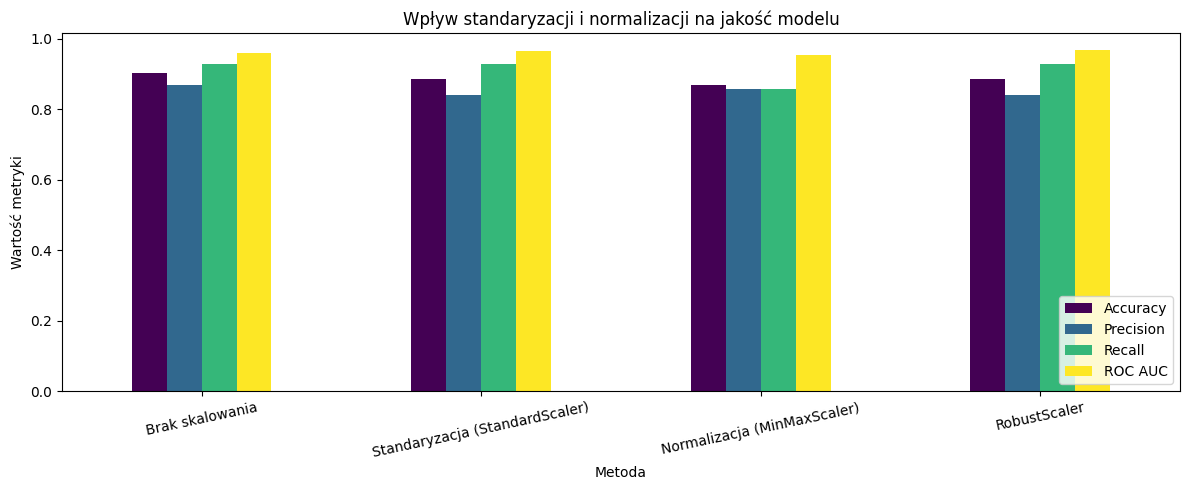

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

scaling_variants = [
    ("Brak skalowania", None),
    ("Standaryzacja (StandardScaler)", StandardScaler()),
    ("Normalizacja (MinMaxScaler)", MinMaxScaler()),
    ("RobustScaler", RobustScaler()),
]

scaling_results = []

for scaling_name, scaling_obj in scaling_variants:
    scaling_model = build_logreg_pipeline(
        scaler=scaling_obj,
        penalty="l2",
        C=0.1,
        solver="lbfgs",
        max_iter=4000,
    )
    scaling_model.fit(X_train, y_train)

    scaling_pred = scaling_model.predict(X_test)
    scaling_proba = scaling_model.predict_proba(X_test)[:, 1]

    scaling_results.append(
        {
            "Metoda skalowania": scaling_name,
            "Accuracy": accuracy_score(y_test, scaling_pred),
            "Precision": precision_score(y_test, scaling_pred, zero_division=0),
            "Recall": recall_score(y_test, scaling_pred, zero_division=0),
            "ROC AUC": roc_auc_score(y_test, scaling_proba),
        }
    )

scaling_df = pd.DataFrame(scaling_results).set_index("Metoda skalowania").round(3)
display(scaling_df)

ax = scaling_df.plot(kind="bar", figsize=(12, 5), colormap="viridis")
ax.set_title("Wpływ standaryzacji i normalizacji na jakość modelu")
ax.set_xlabel("Metoda")
ax.set_ylabel("Wartość metryki")
ax.legend(loc="lower right")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

,Konfiguracja,Accuracy,Precision,Recall,ROC AUC,Iteracje
0,"L2, C=0.1",0.885,0.839,0.929,0.968,16
1,"L2, C=1.0",0.885,0.839,0.929,0.965,22
2,"L2, C=10.0",0.869,0.833,0.893,0.963,24
3,"L1, C=1.0",0.869,0.833,0.893,0.958,156
4,"ElasticNet, C=1.0, l1_ratio=0.3",0.885,0.839,0.929,0.966,109
5,"ElasticNet, C=1.0, l1_ratio=0.7",0.869,0.833,0.893,0.959,189


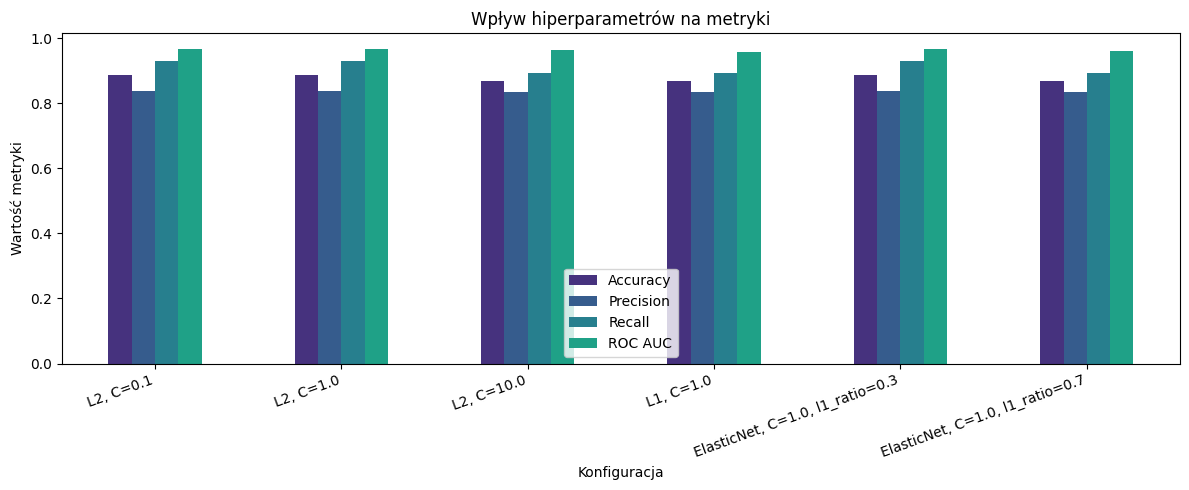

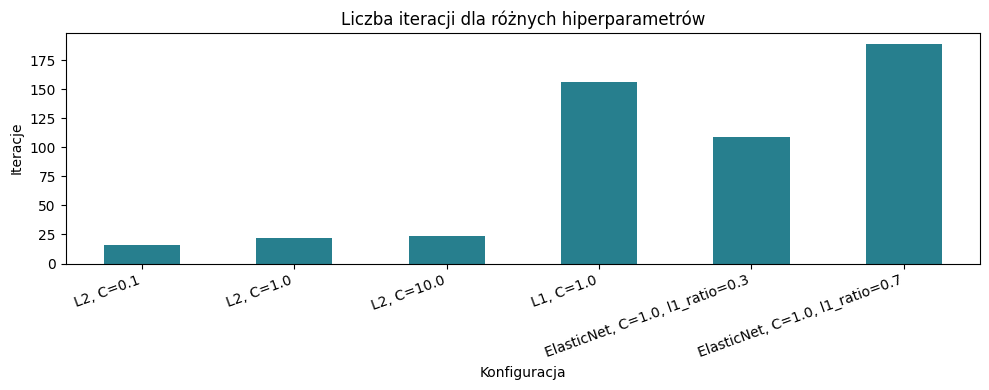

Najlepsza konfiguracja wg ROC AUC: L2, C=0.1
Zakres iteracji: 16 - 189


In [76]:
hyperparam_configs = [
    {"Konfiguracja": "L2, C=0.1", "penalty": "l2", "C": 0.1, "solver": "lbfgs", "l1_ratio": None},
    {"Konfiguracja": "L2, C=1.0", "penalty": "l2", "C": 1.0, "solver": "lbfgs", "l1_ratio": None},
    {"Konfiguracja": "L2, C=10.0", "penalty": "l2", "C": 10.0, "solver": "lbfgs", "l1_ratio": None},
    {"Konfiguracja": "L1, C=1.0", "penalty": "l1", "C": 1.0, "solver": "saga", "l1_ratio": None},
    {"Konfiguracja": "ElasticNet, C=1.0, l1_ratio=0.3", "penalty": "elasticnet", "C": 1.0, "solver": "saga", "l1_ratio": 0.3},
    {"Konfiguracja": "ElasticNet, C=1.0, l1_ratio=0.7", "penalty": "elasticnet", "C": 1.0, "solver": "saga", "l1_ratio": 0.7},
]

hp_rows = []

for cfg in hyperparam_configs:
    model_hp = build_logreg_pipeline(
        scaler=RobustScaler(),
        penalty=cfg["penalty"],
        C=cfg["C"],
        solver=cfg["solver"],
        l1_ratio=cfg["l1_ratio"],
        max_iter=7000,
    )
    model_hp.fit(X_train, y_train)

    pred_hp = model_hp.predict(X_test)
    proba_hp = model_hp.predict_proba(X_test)[:, 1]
    iteracje = int(model_hp.named_steps["classifier"].n_iter_.max())

    hp_rows.append(
        {
            "Konfiguracja": cfg["Konfiguracja"],
            "Accuracy": accuracy_score(y_test, pred_hp),
            "Precision": precision_score(y_test, pred_hp, zero_division=0),
            "Recall": recall_score(y_test, pred_hp, zero_division=0),
            "ROC AUC": roc_auc_score(y_test, proba_hp),
            "Iteracje": iteracje,
        }
    )

hp_df = pd.DataFrame(hp_rows)
display(hp_df.round(3))

viridis_colors = sns.color_palette("viridis", 6)

ax = hp_df.plot(
    x="Konfiguracja",
    y=["Accuracy", "Precision", "Recall", "ROC AUC"],
    kind="bar",
    figsize=(12, 5),
    color=viridis_colors[:4],
)
ax.set_title("Wpływ hiperparametrów na metryki")
ax.set_xlabel("Konfiguracja")
ax.set_ylabel("Wartość metryki")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

ax_iter = hp_df.plot(
    x="Konfiguracja",
    y="Iteracje",
    kind="bar",
    figsize=(10, 4),
    legend=False,
    color=viridis_colors[2],
)
ax_iter.set_title("Liczba iteracji dla różnych hiperparametrów")
ax_iter.set_xlabel("Konfiguracja")
ax_iter.set_ylabel("Iteracje")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

best_row = hp_df.loc[hp_df["ROC AUC"].idxmax()]
print("Najlepsza konfiguracja wg ROC AUC:", best_row["Konfiguracja"])
print(f"Zakres iteracji: {int(hp_df['Iteracje'].min())} - {int(hp_df['Iteracje'].max())}")

### Wnioski z analizy hiperparametrów

- Najlepsza jakość (wg ROC AUC) została osiągnięta dla konfiguracji z regularyzacją L2 i mniejszą wartością C.
- Zmiana rodzaju regularyzacji wpływa nie tylko na metryki, ale też na liczbę iteracji potrzebnych do zbieżności.
- Dla części konfiguracji (szczególnie saga z L1/ElasticNet) model potrzebuje wyraźnie więcej iteracji niż dla lbfgs z L2.

,Metoda,Fold,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,ROC AUC_mean,ROC AUC_std
0,KFold,2,0.852,0.023,0.872,0.057,0.798,0.031,0.918,0.020
1,StratifiedKFold,2,0.832,0.015,0.839,0.051,0.791,0.114,0.910,0.021
2,KFold,5,0.845,0.042,0.858,0.047,0.801,0.077,0.914,0.034
3,StratifiedKFold,5,0.855,0.054,0.874,0.064,0.798,0.081,0.919,0.024
4,KFold,10,0.858,0.056,0.875,0.096,0.806,0.112,0.912,0.058
5,StratifiedKFold,10,0.848,0.065,0.861,0.070,0.799,0.105,0.915,0.046


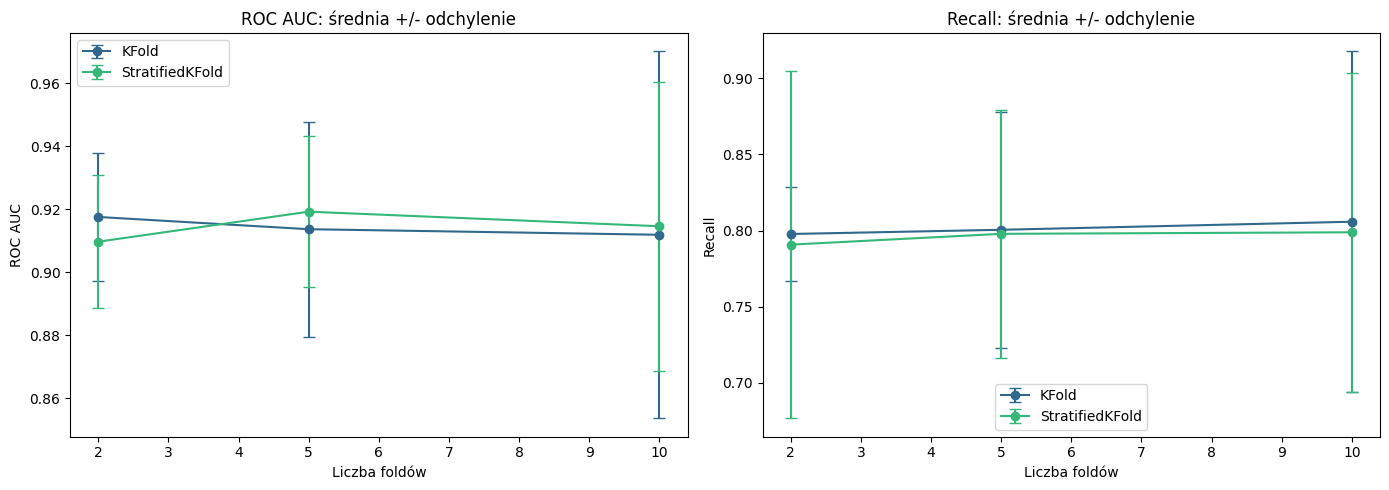

Różnica ROC AUC (StratifiedKFold - KFold):
Fold
2    -0.008
5     0.006
10    0.003


In [77]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate

cv_rows = []
for n_splits in [2, 5, 10]:
    cv_strategies = {
        "KFold": KFold(n_splits=n_splits, shuffle=True, random_state=42),
        "StratifiedKFold": StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42),
    }

    for method_name, cv in cv_strategies.items():
        cv_model = build_logreg_pipeline(
            scaler=RobustScaler(),
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            max_iter=4000,
        )

        cv_results = cross_validate(
            cv_model,
            X,
            y,
            cv=cv,
            scoring=["accuracy", "precision", "recall", "roc_auc"],
            n_jobs=-1,
        )

        cv_rows.append(
            {
                "Metoda": method_name,
                "Fold": n_splits,
                "Accuracy_mean": cv_results["test_accuracy"].mean(),
                "Accuracy_std": cv_results["test_accuracy"].std(ddof=1),
                "Precision_mean": cv_results["test_precision"].mean(),
                "Precision_std": cv_results["test_precision"].std(ddof=1),
                "Recall_mean": cv_results["test_recall"].mean(),
                "Recall_std": cv_results["test_recall"].std(ddof=1),
                "ROC AUC_mean": cv_results["test_roc_auc"].mean(),
                "ROC AUC_std": cv_results["test_roc_auc"].std(ddof=1),
            }
        )

cv_summary = pd.DataFrame(cv_rows).sort_values(["Fold", "Metoda"]).reset_index(drop=True)
display(cv_summary.round(3))

method_colors = {
    "KFold": sns.color_palette("viridis", 2)[0],
    "StratifiedKFold": sns.color_palette("viridis", 2)[1],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for method_name in cv_summary["Metoda"].unique():
    sub = cv_summary[cv_summary["Metoda"] == method_name].sort_values("Fold")

    axes[0].errorbar(
        sub["Fold"],
        sub["ROC AUC_mean"],
        yerr=sub["ROC AUC_std"],
        marker="o",
        capsize=4,
        color=method_colors[method_name],
        label=method_name,
    )
    axes[1].errorbar(
        sub["Fold"],
        sub["Recall_mean"],
        yerr=sub["Recall_std"],
        marker="o",
        capsize=4,
        color=method_colors[method_name],
        label=method_name,
    )

axes[0].set_title("ROC AUC: średnia +/- odchylenie")
axes[0].set_xlabel("Liczba foldów")
axes[0].set_ylabel("ROC AUC")
axes[0].legend()

axes[1].set_title("Recall: średnia +/- odchylenie")
axes[1].set_xlabel("Liczba foldów")
axes[1].set_ylabel("Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

pivot_auc = cv_summary.pivot(index="Fold", columns="Metoda", values="ROC AUC_mean")
if {"KFold", "StratifiedKFold"}.issubset(pivot_auc.columns):
    diff_auc = (pivot_auc["StratifiedKFold"] - pivot_auc["KFold"]).round(3)
    print("Różnica ROC AUC (StratifiedKFold - KFold):")
    print(diff_auc.to_string())

### Wnioski z walidacji krzyżowej

- Porównanie `2/5/10-fold` pokazuje, że średnie metryk są zbliżone, ale ich zmienność zależy od liczby foldów.
- Stratyfikacja stabilizuje podział klas w foldach, co zwykle daje bardziej wiarygodne porównanie wyników.
- Do raportu warto podawać zarówno średnią metrykę, jak i odchylenie standardowe, a nie tylko pojedynczy wynik.